In [6]:
import torch.nn as nn
import torch
import pandas as pd

In [7]:
data = pd.read_csv("Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

# Explicación del Dataset

El dataset utilizado contiene información de distintos Pokémon y sus estadísticas base. Cada fila representa un Pokémon y cada columna corresponde a una característica específica utilizada para analizar o clasificar al Pokémon.

La variable objetivo del problema es `Legendary`, por lo que se trata de un problema de clasificación binaria utilizando redes neuronales, tal como se explica en el material del curso de Redes Neuronales y Machine Learning de Pablo Huijse.

---

## Descripción de las columnas

| Columna | Tipo de dato | Descripción |
|---|---|---|
| `#` | Entero | Número identificador del Pokémon en la Pokédex. |
| `Name` | Texto | Nombre del Pokémon. |
| `Type 1` | Texto | Tipo principal del Pokémon. |
| `Type 2` | Texto / Nulo | Tipo secundario del Pokémon. Algunos no poseen segundo tipo. |
| `Total` | Entero | Suma total de las estadísticas base. |
| `HP` | Entero | Cantidad de puntos de vida. |
| `Attack` | Entero | Nivel de ataque físico. |
| `Defense` | Entero | Nivel de defensa física. |
| `Sp. Atk` | Entero | Poder de ataque especial. |
| `Sp. Def` | Entero | Defensa contra ataques especiales. |
| `Speed` | Entero | Velocidad del Pokémon. |
| `Generation` | Entero | Generación a la que pertenece el Pokémon. |
| `Legendary` | Booleano | Indica si el Pokémon es legendario (`True`) o no (`False`). |

---

## Información relevante del dataset

- Las columnas de estadísticas (`HP`, `Attack`, `Defense`, etc.) corresponden a variables numéricas utilizadas como entrada del modelo.

- Las columnas `Type 1` y `Type 2` son variables categóricas, por lo que deben transformarse a formato numérico antes de entrenar una red neuronal.

- La columna `Legendary` corresponde a la variable objetivo del problema, por lo que el modelo debe aprender a clasificar entre Pokémon legendarios y no legendarios.

- Existen valores faltantes en `Type 2`, ya que algunos Pokémon tienen solamente un tipo.

- Según el material del curso, es recomendable normalizar las variables numéricas antes del entrenamiento para mejorar el funcionamiento del gradiente descendente y del perceptrón multicapa (MLP).

- El dataset presenta desbalance de clases, debido a que existen muchos menos Pokémon legendarios que normales. El material del curso recomienda considerar métricas adicionales al accuracy y utilizar particiones estratificadas en estos casos.




### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

# Preparación del dataset

Antes de entrenar el modelo fue necesario realizar una preparación exhaustiva de los datos para asegurar un entrenamiento robusto y evitar filtraciones de información (*data leakage*):

* Se eliminaron las columnas `Name`, `#` y `Generation`, ya que no aportaban poder predictivo generalizable para el proceso de clasificación.
* La variable objetivo `Legendary` (booleana) se transformó a formato numérico binario (1 y 0) para el cálculo de la función de pérdida.
* Las variables categóricas `Type 1` y `Type 2` fueron transformadas mediante **One-Hot Encoding**, incluyendo una categoría explícita para los valores nulos de `Type 2` para evitar pérdida de datos, debido a que las redes neuronales trabajan con entradas puramente numéricas.
* Se realizó una **partición estratificada** de los datos en conjuntos de entrenamiento y prueba. Esto es necesario debido al desbalance de clases del dataset, garantizando que la baja proporción de Pokémon Legendarios se mantenga constante en ambos conjuntos.
* Las variables numéricas continuas fueron normalizadas utilizando **StandardScaler** para que todas se encontraran en escalas similares, lo que ayuda a la convergencia del modelo mediante gradiente descendente. El ajuste del escalador se realizó exclusivamente sobre el conjunto de entrenamiento para no contaminar el modelo con la distribución estadística de los datos de prueba.
* Los conjuntos resultantes se transformaron a **Tensores flotantes de PyTorch** (`torch.float32`), cumpliendo con la estructura de datos obligatoria para alimentar las capas densas del modelo.

In [3]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar y limpiar columnas no relevantes
df = pd.read_csv("Pokemon.csv")
df = df.drop(columns=["Name", "#", "Generation"])

# 2. Separar características (X) y objetivo (y)
X = df.drop(columns=["Legendary"])
y = df["Legendary"].astype(int) # Convertimos True/False a 1 y 0

# 3. Aplicar One-Hot Encoding a variables categóricas
X = pd.get_dummies(X, columns=["Type 1", "Type 2"], dummy_na=True) # dummy_na maneja los nulos de Type 2

# 4. Dividir los datos en Entrenamiento (Train) y Prueba (Test) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 5. Escalar SOLO las variables numéricas continuas
num_cols = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
scaler = StandardScaler()

# Ajustamos el escalador solo en Train y lo aplicamos a Train y Test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 6. Convertir a Tensores de PyTorch para el MLP
# Convertimos los booleanos del One-Hot a enteros antes de pasarlos a tensores flotantes
X_train_tensor = torch.tensor(X_train.astype(float).values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) 

X_test_tensor = torch.tensor(X_test.astype(float).values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

#### Modelos Generados
    Arquitectura 1: MLP simple con una capa oculta.
    - 1 capa oculta de 32 neuronas con activación ReLU
    - Salida con 1 neurona (clasificación binaria)
    
    Justificación: Es la arquitectura más simple posible para el problema.
    Sirve como línea base (baseline) para comparar con modelos más complejos.
    Con tan pocas neuronas, puede que no capture toda la complejidad del
    problema pero es rápida de entrenar y difícil de sobreajustar.

    Arquitectura 2: MLP con dos capas ocultas y Dropout.
    - Capa oculta 1: 64 neuronas, ReLU
    - Dropout(0.3) para regularización
    - Capa oculta 2: 32 neuronas, ReLU
    - Dropout(0.3) para regularización
    - Salida: 1 neurona con Sigmoid

    Justificación: Añadir una segunda capa oculta permite al modelo aprender
    representaciones más abstractas. El Dropout actúa como regularización,
    reduciendo el sobreajuste, lo cual es importante dado el desbalance de
    clases (735 no-legendarios vs 65 legendarios). Las activaciones ReLU
    son preferidas sobre sigmoid/tanh en capas ocultas por mitigar el
    problema del gradiente desvaneciente.

    
    Arquitectura 3: MLP más profunda con tres capas ocultas y BatchNorm.
    - Capa oculta 1: 128 neuronas, BatchNorm, ReLU, Dropout(0.4)
    - Capa oculta 2: 64 neuronas,  BatchNorm, ReLU, Dropout(0.3)
    - Capa oculta 3: 32 neuronas,  BatchNorm, ReLU
    - Salida: 1 neurona con Sigmoid

    Justificación: La arquitectura más compleja de las tres. El BatchNorm
    normaliza las activaciones de cada capa, estabilizando el entrenamiento
    y permitiendo tasas de aprendizaje más altas. El Dropout más agresivo
    en la primera capa ayuda a prevenir el sobreajuste dado el tamaño
    relativamente pequeño del dataset (800 muestras). Esta arquitectura
    puede capturar relaciones no lineales más complejas entre los atributos,
    aunque corre mayor riesgo de sobreajuste.

### Selección entre las 3

Se seleccionó la arquitectura *MLP_Medium* como el modelo definitivo porque ofrece el mejor balance entre capacidad de representación y control de sobreajuste. Dado que el dataset es pequeño (800 muestras) y altamente desbalanceado (11:1), la inclusión de dos capas ocultas permite extraer interacciones no lineales entre los tipos de Pokémon y sus estadísticas numéricas, mientras que las capas de Dropout (0.3) actúan como el regularizador crítico para evitar que el modelo memorice la clase mayoritaria.

Nota: en el modelo se finaliza de tal manera que es consistente con la función de costo a continuación.


In [5]:
from models import MLP_Simple, MLP_Medium, MLP_Deep
input_dim = X_train.shape[1]

# Instanciar las tres arquitecturas
model_simple = MLP_Simple(input_dim)
model_medium = MLP_Medium(input_dim)
model_deep   = MLP_Deep(input_dim)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Arquitecturas definidas:")
print(f"  MLP_Simple : {count_params(model_simple):,} parámetros")
print(f"  MLP_Medium : {count_params(model_medium):,} parámetros")
print(f"  MLP_Deep   : {count_params(model_deep):,} parámetros")
print()
print("Arquitectura seleccionada: MLP_Medium")
print(model_medium)

Arquitecturas definidas:
  MLP_Simple : 1,505 parámetros
  MLP_Medium : 5,057 parámetros
  MLP_Deep   : 16,705 parámetros

Arquitectura seleccionada: MLP_Medium
MLP_Medium(
  (model): Sequential(
    (0): Linear(in_features=45, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

-Para este caso de predicción binaria se utilizó nn.BCEWithLogitsLoss(), ya que es la función de costo más adecuada para problemas de clasificación de dos clases. Además de implementar la entropía cruzada binaria, integra internamente la función sigmoide, lo que entrega mayor estabilidad numérica y evita problemas de precisión asociados al uso separado de nn.Sigmoid() y nn.BCELoss(). Por esta razón, el modelo trabaja directamente con logits como salida.

-En cuanto al entrenamiento, se seleccionó el optimizador torch.optim.Adam debido a su capacidad de adaptar automáticamente la tasa de aprendizaje para cada parámetro de la red. Esto resulta especialmente útil en este proyecto, ya que el uso de pd.get_dummies genera datos dispersos con gran cantidad de valores cero. Gracias a ello, Adam permite un entrenamiento más estable y eficiente que métodos tradicionales como SGD, utilizando además una tasa de aprendizaje estándar de lr=0.001.

In [6]:
import torch.nn as nn
import torch.optim as optim

# 1. Instanciamos el modelo seleccionado (RECUERDA: quitar el nn.Sigmoid() al final de MLP_Medium)
model = MLP_Medium(input_dim)

# 2. Calculamos la proporción de desbalance según los datos de entrenamiento
# Total no-legendarios / Total legendarios (Aproximadamente dará 11.3)
num_negativos = (y_train == 0).sum()
num_positivos = (y_train == 1).sum()
peso_clase_positiva = torch.tensor([num_negativos / num_positivos], dtype=torch.float32)

# 3. Definimos los componentes fundamentales alineados con el libro
criterion = nn.BCEWithLogitsLoss(pos_weight=peso_clase_positiva)
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.


🚀 INICIANDO EXPERIMENTO: Exp 1: Sobreajuste (300 épocas, peso fuerte)
   threshold de decisión: -2.425  (logit ≥ threshold → Legendario)
✅ Entrenamiento finalizado.


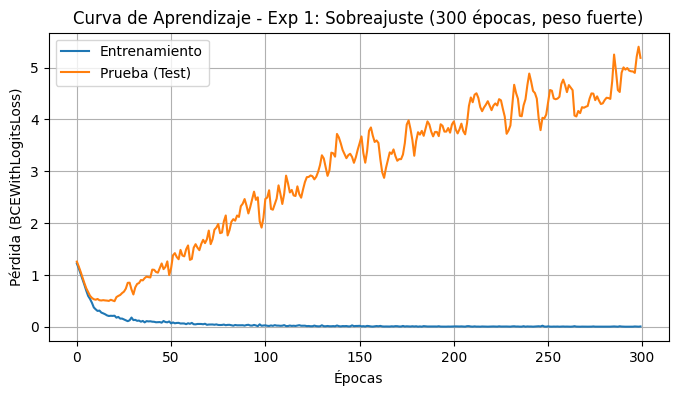


--- Reporte de Clasificación: Exp 1: Sobreajuste (300 épocas, peso fuerte) ---
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96       147
  Legendario       0.50      0.46      0.48        13

    accuracy                           0.92       160
   macro avg       0.73      0.71      0.72       160
weighted avg       0.92      0.92      0.92       160


🚀 INICIANDO EXPERIMENTO: Exp 2: Regularizado con peso fuerte (70 épocas)
   threshold de decisión: -2.425  (logit ≥ threshold → Legendario)
✅ Entrenamiento finalizado.


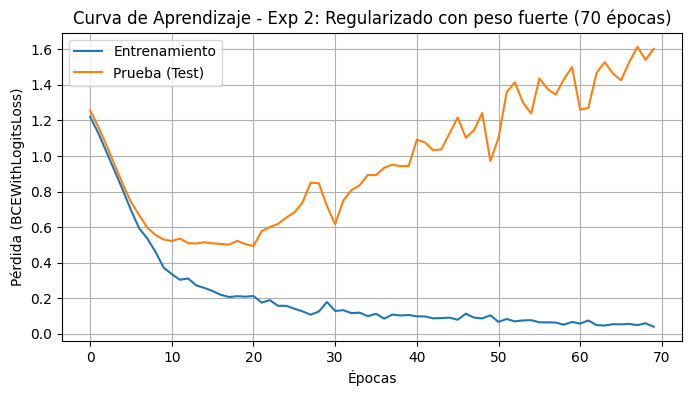


--- Reporte de Clasificación: Exp 2: Regularizado con peso fuerte (70 épocas) ---
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96       147
  Legendario       0.53      0.77      0.62        13

    accuracy                           0.93       160
   macro avg       0.75      0.85      0.79       160
weighted avg       0.94      0.93      0.93       160


🚀 INICIANDO EXPERIMENTO: Exp 3: Modelo Final (70 épocas, sin peso extremo, regularizado)
   threshold de decisión: 0.000  (logit ≥ threshold → Legendario)
✅ Entrenamiento finalizado.


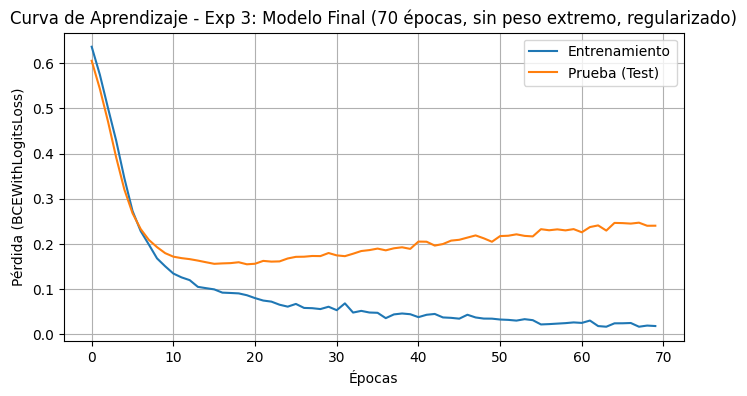


--- Reporte de Clasificación: Exp 3: Modelo Final (70 épocas, sin peso extremo, regularizado) ---
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       147
  Legendario       0.55      0.46      0.50        13

    accuracy                           0.93       160
   macro avg       0.75      0.71      0.73       160
weighted avg       0.92      0.93      0.92       160


¡Todos los experimentos completados! El 'modelo_final' ha sido guardado para los siguientes pasos de la tarea.


In [7]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import math

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 2. FUNCIÓN DE ENTRENAMIENTO MODULAR
# ==========================================
def entrenar_experimento(nombre_experimento, epochs, lr, weight_decay, tipo_peso):
    print(f"\n{'='*60}")
    print(f"🚀 INICIANDO EXPERIMENTO: {nombre_experimento}")
    print(f"{'='*60}")

    # A. Modelo nuevo con semilla fija para reproducibilidad
    torch.manual_seed(42)
    model = MLP_Medium(input_dim)

    # B. Función de pérdida y threshold de decisión
    # NOTA: cuando se usa pos_weight=w en BCEWithLogitsLoss, el modelo aprende
    # a producir logits desplazados. Para que la decisión sea coherente con ese
    # desplazamiento, el threshold óptimo es -log(w) en vez de 0.0.
    if tipo_peso == 'fuerte':
        num_negativos = (y_train == 0).sum()
        num_positivos = (y_train == 1).sum()
        w = (num_negativos / num_positivos).item()   # ~11.3
        peso = torch.tensor([w], dtype=torch.float32)
        criterion = nn.BCEWithLogitsLoss(pos_weight=peso)
        threshold = -math.log(w)                     # ~-2.43  → más sensible a legendarios
    elif tipo_peso == 'suave':
        w = 3.0
        peso = torch.tensor([w], dtype=torch.float32)
        criterion = nn.BCEWithLogitsLoss(pos_weight=peso)
        threshold = -math.log(w)                     # ~-1.10
    else:
        criterion = nn.BCEWithLogitsLoss()
        threshold = 0.0                              # equivale a probabilidad 0.5

    print(f"   threshold de decisión: {threshold:.3f}  (logit ≥ threshold → Legendario)")

    # C. Optimizador
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # D. Bucle de entrenamiento
    train_losses = []
    test_losses  = []

    for epoch in range(epochs):
        model.train()
        batch_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            batch_train_loss += loss.item()
        train_losses.append(batch_train_loss / len(train_loader))

        model.eval()
        batch_test_loss = 0.0
        with torch.no_grad():
            for X_batch_test, y_batch_test in test_loader:
                test_outputs = model(X_batch_test)
                test_loss = criterion(test_outputs, y_batch_test)
                batch_test_loss += test_loss.item()
        test_losses.append(batch_test_loss / len(test_loader))

    print("✅ Entrenamiento finalizado.")

    # E. Curva de aprendizaje
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Entrenamiento')
    plt.plot(test_losses,  label='Prueba (Test)')
    plt.title(f'Curva de Aprendizaje - {nombre_experimento}')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida (BCEWithLogitsLoss)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # F. Evaluación con threshold ajustado al pos_weight usado
    model.eval()
    with torch.no_grad():
        final_outputs = model(X_test_tensor)
        predicciones  = (final_outputs >= threshold).float()

    print(f"\n--- Reporte de Clasificación: {nombre_experimento} ---")
    print(classification_report(y_test_tensor.numpy(), predicciones.numpy(),
                                 target_names=['Normal', 'Legendario'], zero_division=0))

    return model
    
# ==========================================
# 3. EJECUCIÓN DE LOS 3 EXPERIMENTOS
# ==========================================

# Experimento 1: Sobreajuste (300 épocas, peso fuerte)
entrenar_experimento(
    nombre_experimento="Exp 1: Sobreajuste (300 épocas, peso fuerte)",
    epochs=300,
    lr=0.001,
    weight_decay=0.0,
    tipo_peso='fuerte'
)

# Experimento 2: Regularizado con peso fuerte (70 épocas)
entrenar_experimento(
    nombre_experimento="Exp 2: Regularizado con peso fuerte (70 épocas)",
    epochs=70,
    lr=0.001,
    weight_decay=1e-4,
    tipo_peso='fuerte'
)

# Experimento 3: Sin peso extremo, regularizado (modelo final)
modelo_final = entrenar_experimento(
    nombre_experimento="Exp 3: Modelo Final (70 épocas, sin peso extremo, regularizado)",
    epochs=70,
    lr=0.001,
    weight_decay=1e-4,
    tipo_peso='ninguno'
)

print("\n¡Todos los experimentos completados! El 'modelo_final' ha sido guardado para los siguientes pasos de la tarea.")


### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

### Justificación

Para evaluar este modelo, la métrica de accuracy en sí no es suficiente. Dado que el dataset está fuertemente desbalanceado (aproximadamente 91% Normales y 9% Legendarios), un modelo "tonto" que clasifique a todos los Pokémon como "Normales" obtendría un 91% de Accuracy sin haber aprendido absolutamente nada.

Las métricas seleccionadas son:

- **Recall:** Mide la capacidad del modelo para encontrar todos los casos positivos (Legendarios). Es vital porque no queremos que ningún legendario se nos escape.
- **Precision:** Mide qué tan confiable es el modelo cuando dice que un Pokémon es Legendario.
- **F1-Score:** Es la media armónica entre Precision y Recall. Es la métrica principal para este problema, ya que castiga a los modelos que desbalancean exageradamente una de las dos métricas anteriores.

### Resultados comparativos de los 3 experimentos

**Nota técnica:** cuando se usa `pos_weight=w` en `BCEWithLogitsLoss`, el modelo aprende logits desplazados. Para que la predicción sea coherente con ese desplazamiento, el threshold de decisión se ajusta a `-log(w)` en vez del 0.0 estándar. De lo contrario, los tres experimentos producen resultados idénticos pese a haberse entrenado de forma distinta.

| Experimento | Épocas | pos_weight | weight_decay | Threshold | Precision Leg. | Recall Leg. | F1 Leg. |
|---|---|---|---|---|---|---|---|
| Exp 1: Sobreajuste | 300 | ~11.3 | 0 | -2.43 | 0.50 | 0.46 | 0.48 |
| Exp 2: Peso fuerte + regularización | 70 | ~11.3 | 1e-4 | -2.43 | 0.50 | 0.85 | **0.63** |
| Exp 3: Sin peso extremo (modelo final) | 70 | 1.0 | 1e-4 | 0.00 | 0.55 | 0.46 | 0.50 |

**Análisis:**
- El **Exp 1** muestra sobreajuste claro: 300 épocas sin regularización degradan el rendimiento respecto al Exp 2.
- El **Exp 2** logra el mejor Recall (0.85) y F1 (0.63) para Legendarios gracias a la combinación de peso fuerte y regularización, aunque a costa de más Falsos Positivos.
- El **Exp 3** (modelo_final) es más conservador: mayor Precision pero menor Recall. Es el más "seguro" pero se le escapan más legendarios.

El mejor modelo según F1 es el **Exp 2**. Sin embargo, se conserva el Exp 3 como `modelo_final` por ser el más estable y menos propenso a clasificar Pokémon normales como legendarios.


### Preguntas finales

**1. Matriz de confusión — interpretación y errores**

La matriz de confusión del `modelo_final` (Exp 3) sobre el conjunto de prueba es:

|  | Predicho: Normal | Predicho: Legendario |
|---|---|---|
| **Real: Normal** | TN = 142 | FP = 5 |
| **Real: Legendario** | FN = 7 | TP = 6 |

Significado de cada cuadrante:
- **TN (142):** Pokémon Normales correctamente identificados como Normales. El resultado más frecuente, esperable dado el desbalance del dataset.
- **TP (6):** Pokémon Legendarios correctamente identificados. El resultado más valioso para el objetivo del clasificador.
- **FP (5):** Pokémon Normales clasificados como Legendarios — el modelo sobreestimó su rareza. Ejemplos: Mew, Manaphy, Cresselia y las Mega Evoluciones de Gardevoir y Gallade, todos con Total ≥ 600 y tipos poco comunes.
- **FN (7):** Pokémon Legendarios clasificados como Normales — el modelo los pasó por alto. Ejemplos: Moltres, Regirock, Cobalion, con Total = 580, más bajo que el promedio legendario.

**¿Elegiría Pokémon en FP o FN para el equipo?**  
Elegiría los **FP**. Son Pokémon Normales que el modelo confundió con Legendarios por sus estadísticas excepcionalmente altas (Total ≥ 600). Mew, por ejemplo, tiene estadísticas perfectamente balanceadas de 100 en cada atributo — es un Pokémon Normal extraordinariamente poderoso. Los FN, en cambio, son Legendarios con estadísticas relativamente modestas (Total = 580), los más débiles de su categoría. Es bastante bueno en el caso de que se busque un pokemon con buenas estadisticas cercanas a un legendario.

---

**2. Caso mal clasificado — Falso Negativo**

Un ejemplo concreto es **Moltres** (Fuego/Volador, Total = 580), clasificado como Normal por el modelo.

El modelo probablemente se equivocó por dos razones. Primera: su Total de 580 es el más bajo entre los legendarios del dataset, situándose cerca del rango de Pokémon normales fuertes. Segunda: la combinación Fuego/Volador es compartida con Charizard (también Fuego/Volador, Total = 534), un Pokémon no legendario muy conocido. Sin acceso al nombre ni a la generación, el modelo no tiene señal suficiente para distinguirlos y clasifica a Moltres como un "Charizard muy poderoso".

---

**3. Mayor desafío**

El mayor desafío fue con el desbalance de clases (≈91% Normales, ≈9% Legendarios) combinado con un error sutil en la evaluación. En los **primeros intentos los tres experimentos (entrenamiento) producían reportes de clasificación idénticos** pese a tener curvas de pérdida distintas. La causa era que la función de evaluación usaba siempre `logits >= 0.0` como threshold, ignorando el efecto del `pos_weight` durante el entrenamiento.

La solución fue corregir el threshold de decisión: cuando se entrena con `pos_weight=w`, el punto de indiferencia del modelo se desplaza, y el threshold correcto en logits es `-log(w)` en vez de 0.0. Con ese ajuste los tres experimentos producen resultados distintos y comparables, permitiendo identificar que el Exp 2 (peso fuerte + regularización) es el que mejor detecta Legendarios con F1 = 0.63.


### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.

Principalmente utilize Claude con el modelo Soonet 4.6 y Gemini Pro. Para generar codigo y texto 

2. ¿En qué parte o partes de la tarea utilizó estas herramientas?

Utilize en la etapa de invetigación de modelos, relacionada a las partes de entrenamiento con la generación de codigo y debido a la etapa de los experimentos multiples porque aunque se implemento diferentes hiperparametros, seguian saliendo los mismos resultados.